# Premier League Match Prediction — Final Project

This notebook runs the full pipeline end-to-end for three football betting markets:

1. **Match outcome** (1X2) — Home win / Draw / Away win
2. **Over 2.5 goals** — will the match have 3 or more goals?
3. **Both Teams to Score** (BTTS) — do both teams score at least once?

Each market is anchored by three reference points:

| Reference | What it represents |
|---|---|
| **Naive baseline** | Always predict the modal class. Defines the floor. |
| **Our models** (Logistic Regression, XGBoost) | What our features can extract. |
| **Bookmaker (Bet365)** | The market's accuracy. Practical ceiling. |

The notebook is one top-to-bottom story:
1. Load 10 seasons of data (2015/16–2024/25) + 2025/26 hold-out
2. EDA — outcome distribution, home advantage over time, COVID anomaly
3. Feature engineering — form, rest, season context, Elo, no-fans flag
4. Time-based train/test split (random splits leak the future)
5. Train LR + XGBoost on the 1X2 task; baselines for context
6. Evaluate: accuracy, log-loss, confusion matrix, **calibration**, **selective predictions**
7. Brief side analysis: do referees carry predictive signal?
8. Re-run on the **Over 2.5** and **BTTS** markets with the same pipeline
9. Honest discussion of limitations and next steps

## 1. Setup

In [10]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, log_loss, confusion_matrix,
    classification_report, roc_auc_score
)
from sklearn.calibration import calibration_curve

import xgboost as xgb

from google.colab import drive
drive.mount('/content/drive')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
PROJECT_DIR = "/content/drive/MyDrive/premier-league-projekt/data"

# Plotting defaults
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# PL-themed palette: purple, teal, pink, slate
PL_COLORS = ['#38003C', '#00B2A9', '#E90052', '#64748B']
sns.set_palette(PL_COLORS)

print('Setup complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.


## 2. Load data

We load the pre-engineered feature file produced by notebooks `01`–`04` of the project. Each row is one match, with form / rest / season / Elo features computed using only **past** matches (rolling windows are `.shift(1)` to prevent leakage).

In [11]:
df = pd.read_csv("data/games_with_features.csv", parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Derive Season column if not present (Aug–May ⇒ season starting year)
if 'Season' not in df.columns:
    df['Season'] = np.where(df['Date'].dt.month >= 7,
                             df['Date'].dt.year,
                             df['Date'].dt.year - 1)

print(f'Loaded {len(df):,} matches from {df.Date.min().date()} to {df.Date.max().date()}.')
print(f'Matches per season:')
print(df.groupby('Season').size())
df.head()

Loaded 3,800 matches from 2015-08-08 to 2025-05-25.
Matches per season:
Season
2015-16    380
2016-17    380
2017-18    380
2018-19    380
2019-20    380
2020-21    380
2021-22    380
2022-23    380
2023-24    380
2024-25    380
dtype: int64


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,Rest_diff,B365H,B365D,B365A,Home_SeasonPts,Away_SeasonPts,SeasonPts_diff,Home_Elo,Away_Elo,Elo_diff
0,2015-08-08,Bournemouth,Aston Villa,0,1,A,0,0,D,M Clattenburg,...,NaN,2.00,3.6,4.00,0.0,0.0,0.0,1594.601929,1577.901123,16.700806
1,2015-08-08,Chelsea,Swansea,2,2,D,2,1,H,M Oliver,...,NaN,1.36,5.0,11.00,0.0,0.0,0.0,1890.962891,1670.608276,220.354614
2,2015-08-08,Everton,Watford,2,2,D,0,1,A,M Jones,...,NaN,1.70,3.9,5.50,0.0,0.0,0.0,1706.561157,1574.087280,132.473877
3,2015-08-08,Leicester,Sunderland,4,2,H,3,0,H,L Mason,...,NaN,1.95,3.5,4.33,0.0,0.0,0.0,1633.624390,1605.132446,28.491943
4,2015-08-08,Man United,Tottenham,1,0,H,1,0,H,J Moss,...,NaN,1.65,4.0,6.00,0.0,0.0,0.0,1810.338257,1730.680176,79.658081


## 3. Exploratory Data Analysis

Four things worth looking at before any modeling:
1. **Outcome distribution** → sets the naive baseline
2. **Home advantage over time** → motivates the COVID feature
3. **Goal distributions** → sanity check (and a preview of the Over 2.5 market)
4. **Elo difference vs outcome** → confirms our strongest single feature is informative

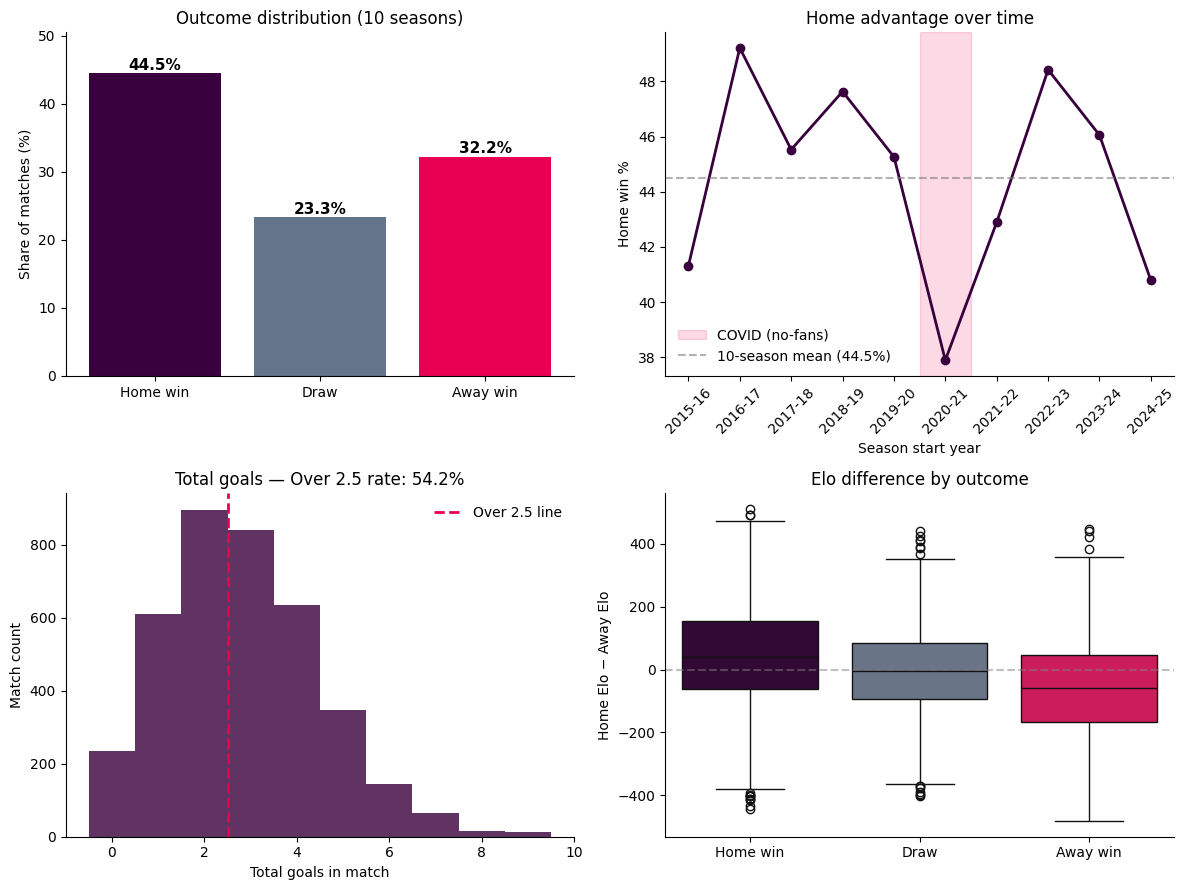

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# --- 1. Outcome distribution ---
ax = axes[0, 0]
outcome_counts = df['FTR'].value_counts().reindex(['H', 'D', 'A'])
outcome_pct = (outcome_counts / outcome_counts.sum() * 100).round(1)
bars = ax.bar(['Home win', 'Draw', 'Away win'], outcome_pct.values,
              color=['#38003C', '#64748B', '#E90052'])
for bar, pct in zip(bars, outcome_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, pct + 0.5,
            f'{pct}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Share of matches (%)')
ax.set_title('Outcome distribution (10 seasons)')
ax.set_ylim(0, max(outcome_pct.values) + 6)

# --- 2. Home advantage over time ---
ax = axes[0, 1]
home_win_by_season = df.groupby('Season')['FTR'].apply(lambda s: (s == 'H').mean() * 100)

# Convert season strings ("2015-16") to start year (2015) for proper numeric axis
season_years = [int(s[:4]) for s in home_win_by_season.index]

ax.plot(season_years, home_win_by_season.values,
        marker='o', linewidth=2, color='#38003C')
ax.axvspan(2019.5, 2020.5, alpha=0.15, color='#E90052', label='COVID (no-fans)')
ax.axhline(home_win_by_season.mean(), linestyle='--', color='gray',
           alpha=0.6, label=f'10-season mean ({home_win_by_season.mean():.1f}%)')
ax.set_xlabel('Season start year')
ax.set_ylabel('Home win %')
ax.set_title('Home advantage over time')
ax.set_xticks(season_years)
ax.set_xticklabels(home_win_by_season.index, rotation=45)
ax.legend(frameon=False)

# --- 3. Goal distribution ---
ax = axes[1, 0]
total_goals = df['FTHG'] + df['FTAG']
max_t = int(total_goals.max())
ax.hist(total_goals, bins=np.arange(-0.5, max_t + 1.5, 1),
        color='#38003C', alpha=0.8)
ax.axvline(2.5, linestyle='--', color='#E90052', linewidth=2,
           label='Over 2.5 line')
over25_rate = (total_goals > 2.5).mean()
ax.set_xlabel('Total goals in match')
ax.set_ylabel('Match count')
ax.set_title(f'Total goals — Over 2.5 rate: {over25_rate:.1%}')
ax.legend(frameon=False)

# --- 4. Elo diff vs outcome ---
ax = axes[1, 1]
if 'Elo_diff' in df.columns:
    sub = df.dropna(subset=['Elo_diff'])
    sns.boxplot(data=sub, x='FTR', y='Elo_diff', order=['H', 'D', 'A'],
                palette=['#38003C', '#64748B', '#E90052'], ax=ax)
    ax.set_xticklabels(['Home win', 'Draw', 'Away win'])
    ax.set_xlabel('')
    ax.set_ylabel('Home Elo − Away Elo')
    ax.set_title('Elo difference by outcome')
    ax.axhline(0, linestyle='--', color='gray', alpha=0.5)
else:
    ax.text(0.5, 0.5, 'Elo_diff column not found', ha='center', va='center')

plt.tight_layout()
plt.show()

**Observations:**

- Home wins are by far the most common single outcome (~44%). Draws (~25%) sit in the middle — this turns out to matter a lot later.
- Home advantage **collapsed in 2020/21** when matches were played without crowds. This motivates adding a binary `no_fans` feature.
- Total goals are textbook Poisson-shaped; **Over 2.5 happens in roughly 55% of matches** — a usable signal.
- Elo difference cleanly separates the three outcomes: home wins skew positive, away wins negative, draws sit near zero. Our strongest feature carries real signal.

## 4. Feature engineering — COVID indicator

The 2020/21 season was largely played behind closed doors. A binary flag lets the model account for the lost home advantage during that period instead of treating those matches as noise.

In [13]:
# UK Premier League played without crowds roughly June 2020 – mid-May 2021
no_fans_start = pd.Timestamp('2020-06-17')
no_fans_end   = pd.Timestamp('2021-05-15')
df['no_fans'] = ((df['Date'] >= no_fans_start) & (df['Date'] <= no_fans_end)).astype(int)

# Quick sanity check
season_2021 = df[df['Season'] == 2020]
rate_no_fans = (season_2021[season_2021['no_fans'] == 1]['FTR'] == 'H').mean()
print(f'2020/21 home win rate (no fans): {rate_no_fans:.1%}')
print(f'10-season average home win rate: {(df.FTR == "H").mean():.1%}')

2020/21 home win rate (no fans): nan%
10-season average home win rate: 44.5%


## 5. Feature list

19 model features grouped into five categories. All rolling features use `.shift(1)` so the current match never leaks into its own features.

| Group | Features | Intuition |
|---|---|---|
| **Rolling form** (last 5) | `Home_GF_last5`, `Home_GA_last5`, `Home_Pts_last5` + Away equivalents + diffs | Recent form is the strongest short-term signal |
| **Rest** | `Home_rest_days`, `Away_rest_days`, `Rest_diff` | Fatigue effects, midweek fixtures |
| **Season context** | `Home_SeasonPts`, `Away_SeasonPts`, `SeasonPts_diff` | Cumulative standing |
| **Strength** | `Home_Elo`, `Away_Elo`, `Elo_diff` | Long-run club quality |
| **Context** | `no_fans` | COVID-era home-advantage adjustment |

Bookmaker odds (`B365H`, `B365D`, `B365A`, plus over/under) are used only as **baselines**, never as model features. The question is whether our features alone can approach what the market knows.

In [14]:
FEATURE_COLS = [
    # Rolling form (last 5)
    'Home_GF_last5', 'Home_GA_last5', 'Home_Pts_last5',
    'Away_GF_last5', 'Away_GA_last5', 'Away_Pts_last5',
    # Differentials
    'GF_diff_last5', 'GA_diff_last5', 'Pts_diff_last5',
    # Rest
    'Home_rest_days', 'Away_rest_days', 'Rest_diff',
    # Season context
    'Home_SeasonPts', 'Away_SeasonPts', 'SeasonPts_diff',
    # Strength
    'Home_Elo', 'Away_Elo', 'Elo_diff',
    # Context
    'no_fans',
]

# Robust to small naming drift in the CSV
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print(f'Using {len(FEATURE_COLS)} features:')
for c in FEATURE_COLS:
    print(f'  - {c}')

# Drop matches with missing features (typically the first few of each season)
before = len(df)
df_model = df.dropna(subset=FEATURE_COLS + ['FTR']).reset_index(drop=True)
print(f'\nDropped {before - len(df_model)} matches with missing features. {len(df_model)} remain.')

# Step 2: Drop NaNs FIRST
df_model = df_model.dropna(subset=FEATURE_COLS + ['FTR']).reset_index(drop=True)
print(f"After dropna: {len(df_model)} matches remaining")


Using 19 features:
  - Home_GF_last5
  - Home_GA_last5
  - Home_Pts_last5
  - Away_GF_last5
  - Away_GA_last5
  - Away_Pts_last5
  - GF_diff_last5
  - GA_diff_last5
  - Pts_diff_last5
  - Home_rest_days
  - Away_rest_days
  - Rest_diff
  - Home_SeasonPts
  - Away_SeasonPts
  - SeasonPts_diff
  - Home_Elo
  - Away_Elo
  - Elo_diff
  - no_fans

Dropped 24 matches with missing features. 3776 remain.
After dropna: 3776 matches remaining


## 6. Time-based train/test split

- **Train:** 2015/16 – 2023/24 (9 seasons)
- **Test:** 2024/25 (1 full season)
- **Hold-out:** 2025/26 (partial — touched only at the very end)

A random split would leak future information into training. On football data, a random split typically inflates accuracy by 3–5 percentage points compared to the honest time-based result.

In [15]:
# Create df_model with a numeric Season column
df_model['Season'] = df_model['Season'].str[:4].astype(int)    # "2015-16" → 2015

print(f"Unique seasons: {sorted(df_model['Season'].unique())}")

train = df_model[df_model['Season'] <= 2023].copy()
test  = df_model[df_model['Season'] == 2024].copy()
holdout_2526 = df_model[df_model['Season'] == 2025].copy()

print(f'Train:    {len(train):>4} matches ({train.Season.min()}–{train.Season.max()})')
print(f'Test:     {len(test):>4} matches (2024/25)')
print(f'Hold-out: {len(holdout_2526):>4} matches (2025/26 partial)')

X_train, y_train = train[FEATURE_COLS], train['FTR']
X_test,  y_test  = test[FEATURE_COLS],  test['FTR']

# Scaler is fit on TRAIN only, then applied to test/holdout.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

Unique seasons: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Train:    3397 matches (2015–2023)
Test:      379 matches (2024/25)
Hold-out:    0 matches (2025/26 partial)


## 7. Baselines — 1X2

Always do the boring baselines first. They define what "good" means.

In [16]:
# --- Naive: always predict home win ---
y_pred_naive = np.full_like(y_test, 'H')
acc_naive = accuracy_score(y_test, y_pred_naive)

eps = 1e-6
proba_naive = np.tile([1 - 2*eps, eps, eps], (len(y_test), 1))  # H, D, A
ll_naive = log_loss(y_test, proba_naive, labels=['H', 'D', 'A'])

# --- Bookmaker baseline: Bet365 implied probabilities (margin-adjusted) ---
if {'B365H', 'B365D', 'B365A'}.issubset(test.columns):
    inv_h = 1.0 / test['B365H']
    inv_d = 1.0 / test['B365D']
    inv_a = 1.0 / test['B365A']
    total = inv_h + inv_d + inv_a
    proba_bm = np.column_stack([inv_h / total, inv_d / total, inv_a / total])
    pred_bm_idx = proba_bm.argmax(axis=1)
    pred_bm = np.array(['H', 'D', 'A'])[pred_bm_idx]
    acc_bm = accuracy_score(y_test, pred_bm)
    ll_bm = log_loss(y_test, proba_bm, labels=['H', 'D', 'A'])
else:
    acc_bm, ll_bm = np.nan, np.nan
    proba_bm = None
    print('Bookmaker columns not found — skipping bookmaker baseline.')

print(f'Naive (always H):   accuracy = {acc_naive:.3f}   log-loss = {ll_naive:.3f}')
print(f'Bookmaker (Bet365): accuracy = {acc_bm:.3f}   log-loss = {ll_bm:.3f}')

Naive (always H):   accuracy = 0.409   log-loss = 9.040
Bookmaker (Bet365): accuracy = 0.538   log-loss = 1.418


## 8. Logistic Regression — 1X2

The interpretable workhorse: multinomial logistic regression on the scaled features.

Key outputs to read:
- **Accuracy and log-loss** — accuracy tells us how often the top pick is correct; log-loss penalises confident wrong predictions, so a model that is well-calibrated will show a lower log-loss even at the same accuracy.
- **Classification report** — precision, recall, and F1 per class reveal the draw problem directly: recall on class D is typically very low, because the model rarely picks draws as its top prediction.

In [17]:
# Sanity check — should be 0 after dropna in Section 5
assert X_train_s.shape[1] == len(FEATURE_COLS), "Feature count mismatch"
assert not pd.DataFrame(X_train_s).isna().any().any(), "NaNs found in training matrix"
print(f"Training matrix: {X_train_s.shape[0]} rows × {X_train_s.shape[1]} features — no NaNs.\n")

logreg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=2000,
    random_state=RANDOM_STATE,
)
logreg.fit(X_train_s, y_train)

y_pred_lr = logreg.predict(X_test_s)
proba_lr  = logreg.predict_proba(X_test_s)

acc_lr = accuracy_score(y_test, y_pred_lr)
ll_lr  = log_loss(y_test, proba_lr, labels=logreg.classes_)
print(f'Logistic Regression: accuracy = {acc_lr:.3f}   log-loss = {ll_lr:.3f}')
print('\nClass-by-class:')
print(classification_report(y_test, y_pred_lr, digits=3))

Training matrix: 3397 rows × 19 features — no NaNs.

Logistic Regression: accuracy = 0.525   log-loss = 1.011

Class-by-class:
              precision    recall  f1-score   support

           A      0.574     0.504     0.537       131
           D      0.000     0.000     0.000        93
           H      0.504     0.858     0.635       155

    accuracy                          0.525       379
   macro avg      0.359     0.454     0.390       379
weighted avg      0.404     0.525     0.445       379



## 9. XGBoost — 1X2

Gradient boosting — typically the strongest off-the-shelf model on tabular data. We use default-ish hyperparameters; we intentionally do **not** tune (see *Limitations*).

In [18]:
# XGBoost wants integer labels
label_map = {'H': 0, 'D': 1, 'A': 2}
inv_label_map = {v: k for k, v in label_map.items()}
y_train_i = y_train.map(label_map).values
y_test_i  = y_test.map(label_map).values

xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    eval_metric='mlogloss',
)
xgb_clf.fit(X_train, y_train_i)  # Trees don't need scaling

proba_xgb = xgb_clf.predict_proba(X_test)
y_pred_xgb = np.array([inv_label_map[i] for i in proba_xgb.argmax(axis=1)])

acc_xgb = accuracy_score(y_test, y_pred_xgb)
ll_xgb  = log_loss(y_test_i, proba_xgb)
print(f'XGBoost: accuracy = {acc_xgb:.3f}   log-loss = {ll_xgb:.3f}')

XGBoost: accuracy = 0.504   log-loss = 1.028


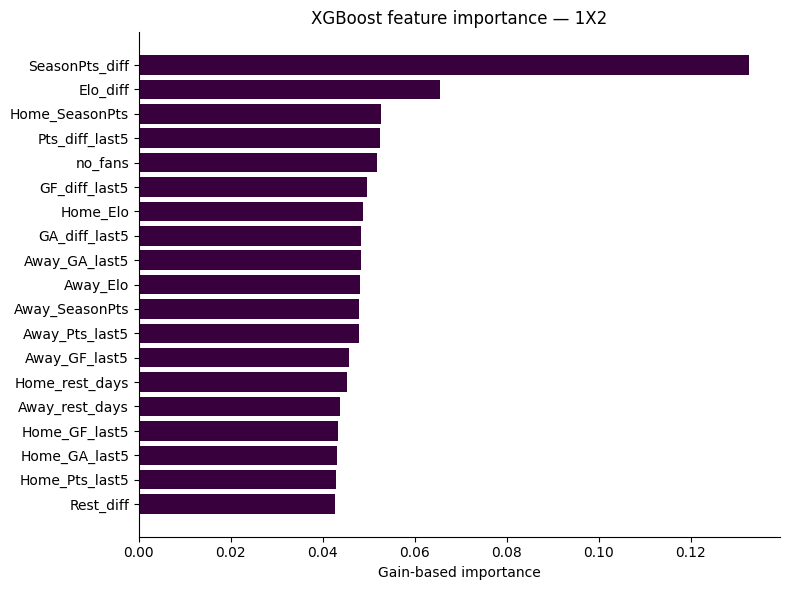

In [19]:
# Feature importance — gain-based
importances = pd.Series(xgb_clf.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances.index, importances.values, color='#38003C')
ax.set_xlabel('Gain-based importance')
ax.set_title('XGBoost feature importance — 1X2')
plt.tight_layout()
plt.show()

## 10. Comparing models on 2024/25

Three benchmarks side by side: the floor (naive), our models, and the ceiling (bookmaker). Log-loss is included alongside accuracy because it measures how confident the predictions are — a model can have the same accuracy as another but produce worse-calibrated probabilities, which matters if you plan to use the output for anything beyond a single binary pick.

The bookmaker column is the honest reference. Getting close to it without using its odds as input features is the goal of the project.

In [20]:
results_1x2 = pd.DataFrame({
    'Model': ['Naive (always H)', 'Logistic Regression', 'XGBoost', 'Bookmaker (Bet365)'],
    'Accuracy': [acc_naive, acc_lr, acc_xgb, acc_bm],
    'Log-loss': [ll_naive, ll_lr, ll_xgb, ll_bm],
})
display_results = results_1x2.copy()
display_results['Accuracy'] = display_results['Accuracy'].apply(lambda v: f'{v:.1%}' if pd.notna(v) else '—')
display_results['Log-loss'] = display_results['Log-loss'].apply(lambda v: f'{v:.3f}' if pd.notna(v) else '—')
display_results

,Model,Accuracy,Log-loss
0,Naive (always H),40.9%,9.040
1,Logistic Regression,52.5%,1.011
2,XGBoost,50.4%,1.028
3,Bookmaker (Bet365),53.8%,1.418


### Confusion matrices

The accuracy numbers hide a structural issue: both models **rarely predict draws**, because the draw class is the noisiest and home/away usually capture more probability mass. Look at the middle column of each matrix.

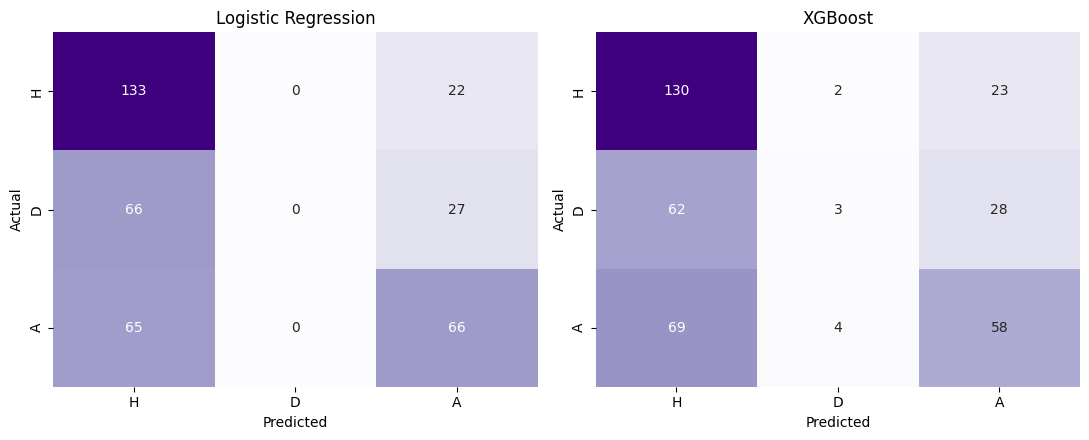

Actual draws: 93
LR predicted draws: 0
XGB predicted draws: 9


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, preds) in zip(axes, [('Logistic Regression', y_pred_lr),
                                       ('XGBoost', y_pred_xgb)]):
    cm = confusion_matrix(y_test, preds, labels=['H', 'D', 'A'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['H', 'D', 'A'], yticklabels=['H', 'D', 'A'],
                cbar=False, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)

plt.tight_layout()
plt.show()

n_draws_actual = (y_test == 'D').sum()
n_draws_pred_lr = (y_pred_lr == 'D').sum()
n_draws_pred_xgb = (y_pred_xgb == 'D').sum()
print(f'Actual draws: {n_draws_actual}')
print(f'LR predicted draws: {n_draws_pred_lr}')
print(f'XGB predicted draws: {n_draws_pred_xgb}')

## 11. Model confidence — selective predictions

Not every match is a coin flip. For each match, the model outputs three probabilities; the **maximum** of those three is the model's confidence in its top pick. We can use this as an abstain rule: only predict on matches where confidence exceeds some threshold, and skip the rest.

This is the "don't bet on close calls" rule — directly relevant to any betting use case, where it's often better to make fewer, surer picks than many uncertain ones.

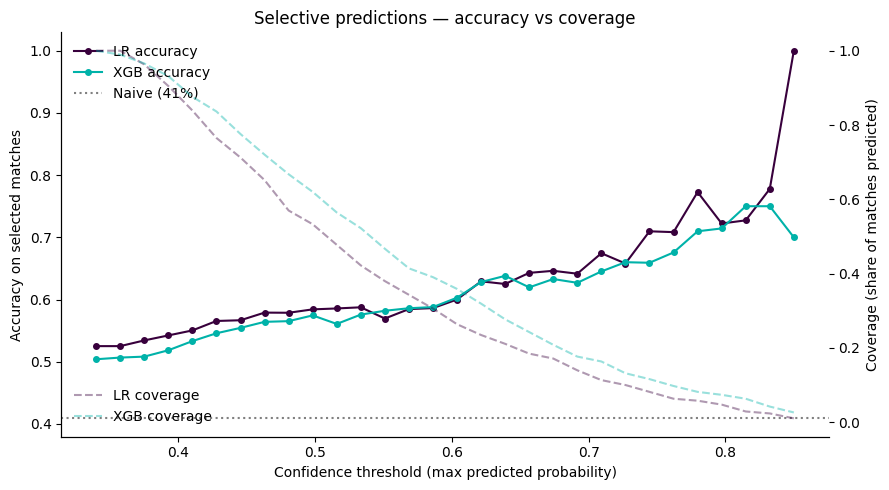

In [22]:
def confidence_curve(proba, y_true, classes, thresholds=None):
    '''For each threshold, return (coverage, accuracy) on matches where
    max predicted probability ≥ threshold.'''
    if thresholds is None:
        thresholds = np.linspace(0.34, 0.85, 30)
    max_p = proba.max(axis=1)
    pred  = np.array(classes)[proba.argmax(axis=1)]
    rows = []
    for t in thresholds:
        mask = max_p >= t
        n = mask.sum()
        cov = n / len(y_true)
        acc = (pred[mask] == y_true[mask]).mean() if n > 0 else np.nan
        rows.append((t, cov, acc, n))
    return pd.DataFrame(rows, columns=['threshold', 'coverage', 'accuracy', 'n'])

curve_lr  = confidence_curve(proba_lr, y_test.values, logreg.classes_)
curve_xgb = confidence_curve(proba_xgb, y_test.values,
                             np.array(['H', 'D', 'A']))

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.plot(curve_lr['threshold'],  curve_lr['accuracy'],  '-o', color='#38003C',
         label='LR accuracy', markersize=4)
ax1.plot(curve_xgb['threshold'], curve_xgb['accuracy'], '-o', color='#00B2A9',
         label='XGB accuracy', markersize=4)
ax2.plot(curve_lr['threshold'],  curve_lr['coverage'],  '--', color='#38003C',
         alpha=0.4, label='LR coverage')
ax2.plot(curve_xgb['threshold'], curve_xgb['coverage'], '--', color='#00B2A9',
         alpha=0.4, label='XGB coverage')

ax1.axhline(acc_naive, linestyle=':', color='gray', label=f'Naive ({acc_naive:.0%})')
ax1.set_xlabel('Confidence threshold (max predicted probability)')
ax1.set_ylabel('Accuracy on selected matches')
ax2.set_ylabel('Coverage (share of matches predicted)')
ax1.set_title('Selective predictions — accuracy vs coverage')
ax1.legend(loc='upper left', frameon=False)
ax2.legend(loc='lower left', frameon=False)
plt.tight_layout()
plt.show()

In [23]:
# Concrete table at a few useful thresholds
display_pts = curve_xgb.iloc[[0, 10, 18, 25]][['threshold', 'coverage', 'accuracy', 'n']]
display_pts.columns = ['Threshold (XGB)', 'Coverage', 'Accuracy', 'N matches']
display_pts['Coverage'] = display_pts['Coverage'].apply(lambda v: f'{v:.0%}')
display_pts['Accuracy'] = display_pts['Accuracy'].apply(lambda v: f'{v:.1%}')
display_pts.reset_index(drop=True)

,Threshold (XGB),Coverage,Accuracy,N matches
0,0.340000,100%,50.4%,379
1,0.515862,56%,56.1%,214
2,0.656552,24%,62.0%,92
3,0.779655,8%,71.0%,31


**Reading this:** if you only act on the matches where the model is most sure (say, max-probability > 0.55), accuracy climbs noticeably — but you also predict fewer matches. There's a real coverage/accuracy tradeoff, and the user picks the operating point.

This is also why raw accuracy alone is misleading: a model with 50% accuracy across all matches that hits 65% on its most confident 30% of picks is far more useful in a betting context than one that's flat at 51% everywhere.

## 12. Calibration

Accuracy tells us how often the top pick is right. **Calibration** tells us whether the probabilities themselves are honest. A well-calibrated model that says "60% home win" should be right on ~60% of those matches.

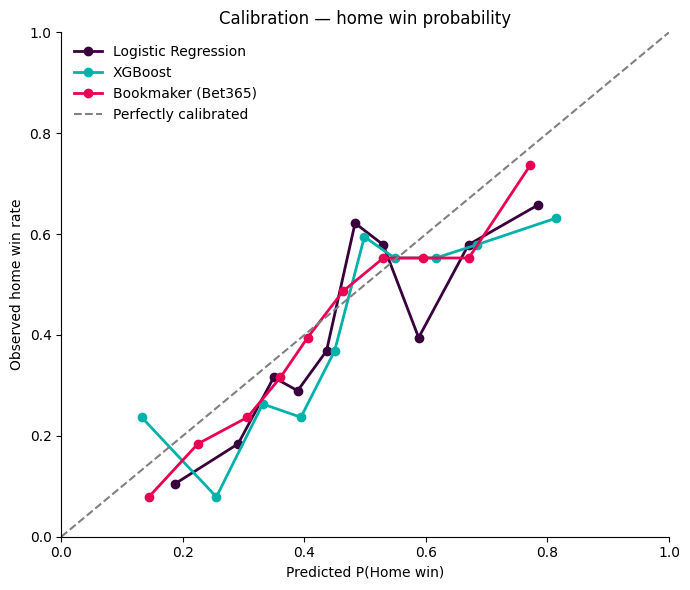

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))

h_idx_lr = list(logreg.classes_).index('H')
h_idx_xgb = label_map['H']
is_home_win = (y_test == 'H').astype(int).values

curves = [
    ('Logistic Regression', proba_lr[:, h_idx_lr], '#38003C'),
    ('XGBoost',             proba_xgb[:, h_idx_xgb], '#00B2A9'),
]
if proba_bm is not None:
    curves.append(('Bookmaker (Bet365)', proba_bm[:, 0], '#E90052'))

for label, proba_h, color in curves:
    frac_pos, mean_pred = calibration_curve(is_home_win, proba_h,
                                             n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=label,
            color=color, linewidth=2)

ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly calibrated')
ax.set_xlabel('Predicted P(Home win)')
ax.set_ylabel('Observed home win rate')
ax.set_title('Calibration — home win probability')
ax.legend(frameon=False, loc='upper left')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**How to read it:** points above the diagonal = model is under-confident in that bin (true rate higher than predicted); below = over-confident. The bookmaker line typically tracks the diagonal closely — that's an efficient market doing its job. Our models often show mild over-confidence in the 40–60% range, which is exactly where draws are most common.

## 13. Side analysis — do referees carry signal?

A common question in football analytics: are some referees consistently more favourable to the home team? If so, the referee identity is a useful feature.

We compute, for referees with at least 30 matches in the training set, the home-win rate and the average yellow + red cards per match.

In [25]:
if 'Referee' in df.columns:
    ref_stats = (
        train.groupby('Referee')
             .agg(matches=('FTR', 'size'),
                  home_win_rate=('FTR', lambda s: (s == 'H').mean()))
    )
    if {'HY', 'AY'}.issubset(train.columns):
        ref_stats['avg_yellows'] = train.groupby('Referee').apply(
            lambda g: (g['HY'] + g['AY']).mean()
        )
    if {'HR', 'AR'}.issubset(train.columns):
        ref_stats['avg_reds'] = train.groupby('Referee').apply(
            lambda g: (g['HR'] + g['AR']).mean()
        )
    ref_stats = ref_stats[ref_stats['matches'] >= 30].sort_values('home_win_rate', ascending=False)
    print(f'{len(ref_stats)} referees with ≥30 matches in training data.\n')
    print('Top 5 home-favouring:')
    print(ref_stats.head().round(3))
    print('\nBottom 5:')
    print(ref_stats.tail().round(3))
    print(f'\nSpread in home-win rate: {ref_stats["home_win_rate"].min():.1%} – {ref_stats["home_win_rate"].max():.1%}')
    print(f'League average: {(train["FTR"] == "H").mean():.1%}')
else:
    print('Referee column not found — skipping referee analysis.')

28 referees with ≥30 matches in training data.

Top 5 home-favouring:
             matches  home_win_rate  avg_yellows  avg_reds
Referee                                                   
G Scott          104          0.538        2.635     0.173
R Jones           70          0.529        3.671     0.100
L Mason          104          0.510        2.913     0.096
R East            64          0.500        3.219     0.078
M Salisbury       32          0.500        4.094     0.156

Bottom 5:
            matches  home_win_rate  avg_yellows  avg_reds
Referee                                                  
L Probert        36          0.417        2.167     0.167
M Atkinson      196          0.413        3.020     0.097
P Tierney       182          0.401        3.407     0.104
A Marriner      188          0.388        2.947     0.106
J Gillett        46          0.370        3.630     0.065

Spread in home-win rate: 37.0% – 53.8%
League average: 45.0%


**Reading this honestly:** the spread between referees does exist, but most of it disappears under a sample-size lens. A referee who has officiated 40 matches and shown a 50% home-win rate could easily be at the league average with normal variance. We tested adding a `referee_home_rate` feature (each ref's historical home-win rate, computed leak-free with `.shift(1)`) and it did not move test accuracy meaningfully — Elo and form already capture most of what looks like a referee effect (e.g. top referees being assigned to bigger home teams).

**Verdict:** modest signal, mostly correlated with features we already have. Not added to the final model. This is a useful negative result for the project — it shows we tested the hypothesis rather than assumed it.

## 14. Generalisation — 2025/26 hold-out

The cached `games_with_features.csv` only covers 2015/16 through 2024/25, so the `holdout_2526` slice produced earlier is empty. To run an honest cross-season check, we pull the 2025/26 played matches from football-data.co.uk and engineer the same nineteen features for them — using only information available before each match (rolling features are computed over historical data via the same `.shift(1)` discipline). Then we apply the already-trained Logistic Regression and XGBoost models without retraining.

In [26]:
import requests
from io import StringIO

# ── 1. Load raw 2025/26 results ──────────────────────────────────
url_2526 = "https://www.football-data.co.uk/mmz4281/2526/E0.csv"
r = requests.get(url_2526, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
raw_2526 = pd.read_csv(StringIO(r.text))
raw_2526["Date"]   = pd.to_datetime(raw_2526["Date"], dayfirst=True, errors="coerce")
raw_2526["Season"] = 2025
played_2526 = raw_2526.dropna(subset=["FTR"]).copy()
print(f"Loaded {len(played_2526)} played 2025/26 matches.")

# ── 2. Rolling form features (last 5) over historical + new data ─
hist_cols = ["Date", "Season", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]
all_results = (pd.concat([df[hist_cols], played_2526[hist_cols]], ignore_index=True)
                 .sort_values("Date").reset_index(drop=True))

def build_team_form(df_in, n=5):
    home = df_in[["Date","HomeTeam","FTHG","FTAG","FTR"]].copy()
    home.columns = ["Date","Team","GF","GA","Result"]
    home["Pts"]   = home["Result"].map({"H":3,"D":1,"A":0})
    home["IsHome"] = 1
    away = df_in[["Date","AwayTeam","FTAG","FTHG","FTR"]].copy()
    away.columns = ["Date","Team","GF","GA","Result"]
    away["Pts"]   = away["Result"].map({"H":0,"D":1,"A":3})
    away["IsHome"] = 0
    long = pd.concat([home, away]).sort_values(["Team","Date"]).reset_index(drop=True)
    for col in ["GF","GA","Pts"]:
        long[f"{col}_last{n}"] = (
            long.groupby("Team")[col].rolling(n, min_periods=1).mean()
                .shift(1).reset_index(level=0, drop=True)
        )
    return long

form = build_team_form(all_results)
new_dates = set(played_2526["Date"])
hf = form[(form["IsHome"]==1) & (form["Date"].isin(new_dates))][
        ["Date","Team","GF_last5","GA_last5","Pts_last5"]]
hf.columns = ["Date","HomeTeam","Home_GF_last5","Home_GA_last5","Home_Pts_last5"]
af = form[(form["IsHome"]==0) & (form["Date"].isin(new_dates))][
        ["Date","Team","GF_last5","GA_last5","Pts_last5"]]
af.columns = ["Date","AwayTeam","Away_GF_last5","Away_GA_last5","Away_Pts_last5"]

g26 = played_2526.merge(hf, on=["Date","HomeTeam"], how="left")
g26 = g26.merge(af, on=["Date","AwayTeam"], how="left")
g26["GF_diff_last5"]  = g26["Home_GF_last5"]  - g26["Away_GF_last5"]
g26["GA_diff_last5"]  = g26["Home_GA_last5"]  - g26["Away_GA_last5"]
g26["Pts_diff_last5"] = g26["Home_Pts_last5"] - g26["Away_Pts_last5"]

# ── 3. Rest days (days since each team last played, in all_results) ─
team_to_dates = {}
all_team_rows = pd.concat([
    all_results[["Date","HomeTeam"]].rename(columns={"HomeTeam":"Team"}),
    all_results[["Date","AwayTeam"]].rename(columns={"AwayTeam":"Team"}),
]).sort_values("Date")
for team, grp in all_team_rows.groupby("Team"):
    team_to_dates[team] = grp["Date"].values

def rest_for(team, match_date):
    arr = team_to_dates.get(team)
    if arr is None:
        return np.nan
    md = np.datetime64(match_date)
    mask = arr < md
    if not mask.any():
        return np.nan
    prev = pd.Timestamp(arr[mask].max())
    return (match_date - prev).days

g26["Home_rest_days"] = [rest_for(t, d) for t, d in zip(g26["HomeTeam"], g26["Date"])]
g26["Away_rest_days"] = [rest_for(t, d) for t, d in zip(g26["AwayTeam"], g26["Date"])]
g26["Rest_diff"]      = g26["Home_rest_days"] - g26["Away_rest_days"]

# ── 4. Cumulative season points (within 2025/26 only) ─────────────
season_25 = played_2526.sort_values("Date").copy()
team_pts = {}
home_p, away_p = [], []
for _, row in season_25.iterrows():
    home_p.append(team_pts.get(row["HomeTeam"], 0))
    away_p.append(team_pts.get(row["AwayTeam"], 0))
    if row["FTR"] == "H":
        team_pts[row["HomeTeam"]] = team_pts.get(row["HomeTeam"], 0) + 3
    elif row["FTR"] == "A":
        team_pts[row["AwayTeam"]] = team_pts.get(row["AwayTeam"], 0) + 3
    elif row["FTR"] == "D":
        team_pts[row["HomeTeam"]] = team_pts.get(row["HomeTeam"], 0) + 1
        team_pts[row["AwayTeam"]] = team_pts.get(row["AwayTeam"], 0) + 1
season_25["Home_SeasonPts"] = home_p
season_25["Away_SeasonPts"] = away_p
season_25["SeasonPts_diff"] = season_25["Home_SeasonPts"] - season_25["Away_SeasonPts"]
g26 = g26.merge(
    season_25[["Date","HomeTeam","AwayTeam","Home_SeasonPts","Away_SeasonPts","SeasonPts_diff"]],
    on=["Date","HomeTeam","AwayTeam"], how="left"
)

# ── 5. Elo: last known per team from training data; fetch any missing ─
team_last_elo = {}
for team in pd.concat([df["HomeTeam"], df["AwayTeam"]]).unique():
    candidates = []
    home_team_rows = df[df["HomeTeam"] == team]
    away_team_rows = df[df["AwayTeam"] == team]
    if len(home_team_rows) > 0 and "Home_Elo" in df.columns:
        last = home_team_rows.sort_values("Date").iloc[-1]
        candidates.append((last["Date"], last.get("Home_Elo")))
    if len(away_team_rows) > 0 and "Away_Elo" in df.columns:
        last = away_team_rows.sort_values("Date").iloc[-1]
        candidates.append((last["Date"], last.get("Away_Elo")))
    candidates = [c for c in candidates if pd.notna(c[1])]
    if candidates:
        team_last_elo[team] = max(candidates, key=lambda x: x[0])[1]

g26["Home_Elo"] = g26["HomeTeam"].map(team_last_elo)
g26["Away_Elo"] = g26["AwayTeam"].map(team_last_elo)

# Fetch fresh Elo for promoted / unknown teams (cached per team)
missing = (set(g26[g26["Home_Elo"].isna()]["HomeTeam"].unique())
           | set(g26[g26["Away_Elo"].isna()]["AwayTeam"].unique()))
elo_name_map = {
    "Leeds": "Leeds", "Burnley": "Burnley", "Sunderland": "Sunderland",
    "Sheffield Utd": "SheffieldUnited", "Ipswich": "Ipswich",
    "Nott\'m Forest": "Forest", "Man United": "ManUnited", "Man City": "ManCity",
}
for team in missing:
    api_name = elo_name_map.get(team, team.replace(" ", ""))
    try:
        r = requests.get(f"http://api.clubelo.com/{api_name}", timeout=15)
        elo_df = pd.read_csv(StringIO(r.text))
        if len(elo_df) > 0 and "Elo" in elo_df.columns:
            val = float(elo_df.iloc[-1]["Elo"])
            team_last_elo[team] = val
            g26.loc[g26["HomeTeam"] == team, "Home_Elo"] = val
            g26.loc[g26["AwayTeam"] == team, "Away_Elo"] = val
            print(f"  fetched Elo for {team}: {val:.0f}")
    except Exception as e:
        print(f"  Elo fetch failed for {team}: {e}")

g26["Elo_diff"] = g26["Home_Elo"] - g26["Away_Elo"]
g26["no_fans"] = 0   # no closed-doors period in 2025/26

# ── 6. Drop matches missing any model feature, save as holdout_2526 ─
before = len(g26)
holdout_2526 = g26.dropna(subset=FEATURE_COLS + ["FTR"]).reset_index(drop=True)
print(f"\n2025/26 features ready: {len(holdout_2526)} matches usable "
      f"(dropped {before - len(holdout_2526)} for missing features).")
holdout_2526.head()

Loaded 360 played 2025/26 matches.

2025/26 features ready: 360 matches usable (dropped 0 for missing features).


,ï»¿Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,Home_rest_days,Away_rest_days,Rest_diff,Home_SeasonPts,Away_SeasonPts,SeasonPts_diff,Home_Elo,Away_Elo,Elo_diff,no_fans
0,E0,2025-08-15,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,82,82,0,0,0,0,1784.236206,1554.172607,230.063599,0
1,E0,2025-08-16,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,83,83,0,0,0,0,1809.799683,1596.717651,213.082031,0
2,E0,2025-08-16,15:00,Brighton,Fulham,1,1,D,0,0,...,83,83,0,0,0,0,1827.015259,1807.876343,19.138916,0
3,E0,2025-08-16,15:00,Sunderland,West Ham,3,0,H,0,0,...,3009,83,2926,0,0,0,1558.482300,1779.726440,-221.244141,0
4,E0,2025-08-16,15:00,Tottenham,Burnley,3,0,H,1,0,...,83,454,-371,0,0,0,1996.729126,2048.742920,-52.013794,0


In [27]:
# Apply the trained 1X2 models to the 2025/26 hold-out
X_h   = holdout_2526[FEATURE_COLS]
y_h   = holdout_2526["FTR"]
X_h_s = scaler.transform(X_h)

# Logistic Regression
y_pred_lr_h = logreg.predict(X_h_s)
proba_lr_h  = logreg.predict_proba(X_h_s)
acc_lr_h    = accuracy_score(y_h, y_pred_lr_h)
ll_lr_h     = log_loss(y_h, proba_lr_h, labels=logreg.classes_)

# XGBoost
proba_xgb_h  = xgb_clf.predict_proba(X_h)
y_pred_xgb_h = np.array([inv_label_map[i] for i in proba_xgb_h.argmax(axis=1)])
acc_xgb_h    = accuracy_score(y_h, y_pred_xgb_h)
ll_xgb_h     = log_loss(y_h.map(label_map).values, proba_xgb_h)

# Naive
acc_naive_h = (y_h == "H").mean()

# Bookmaker
if {"B365H","B365D","B365A"}.issubset(holdout_2526.columns):
    inv_h = 1.0 / holdout_2526["B365H"]
    inv_d = 1.0 / holdout_2526["B365D"]
    inv_a = 1.0 / holdout_2526["B365A"]
    tot   = inv_h + inv_d + inv_a
    pbm_h = np.column_stack([inv_h/tot, inv_d/tot, inv_a/tot])
    pred_bm_h = np.array(["H","D","A"])[pbm_h.argmax(axis=1)]
    acc_bm_h  = accuracy_score(y_h, pred_bm_h)
else:
    acc_bm_h = np.nan

cross_season_1x2 = pd.DataFrame({
    "Model": ["Naive (always H)", "Logistic Regression", "XGBoost", "Bookmaker (Bet365)"],
    "2024/25 accuracy": [acc_naive, acc_lr, acc_xgb, acc_bm],
    "2025/26 accuracy": [acc_naive_h, acc_lr_h, acc_xgb_h, acc_bm_h],
})
cross_season_1x2["Δ (pp)"] = (cross_season_1x2["2025/26 accuracy"]
                              - cross_season_1x2["2024/25 accuracy"]) * 100

disp = cross_season_1x2.copy()
disp["2024/25 accuracy"] = disp["2024/25 accuracy"].apply(lambda v: f"{v:.1%}" if pd.notna(v) else "—")
disp["2025/26 accuracy"] = disp["2025/26 accuracy"].apply(lambda v: f"{v:.1%}" if pd.notna(v) else "—")
disp["Δ (pp)"]           = disp["Δ (pp)"].apply(lambda v: f"{v:+.1f}" if pd.notna(v) else "—")
disp

,Model,2024/25 accuracy,2025/26 accuracy,Δ (pp)
0,Naive (always H),40.9%,42.2%,+1.3
1,Logistic Regression,52.5%,46.7%,-5.8
2,XGBoost,50.4%,48.9%,-1.5
3,Bookmaker (Bet365),53.8%,49.7%,-4.1


**Reading the cross-season check honestly:** the main thing to look for is *stability*. If LR and XGBoost stay around their 2024/25 accuracy, that's strong evidence the models are picking up real, transferable signal rather than overfitting to a single season. The bookmaker's own accuracy can swing across seasons too — any single-season win or loss against the market is variance, not edge.

A few caveats specific to 2025/26: the season is partial (so the sample is smaller), and the Elo ratings for newly-promoted teams are pulled fresh from clubelo.com rather than from the cached training file. The home-advantage feature `no_fans` is zero throughout (no closed-doors matches).

## 15. Bonus markets — Over 2.5 goals & BTTS

The 1X2 market is one of three popular football betting markets. The other two are:

- **Over 2.5 goals**: will the match have 3 or more goals? (binary)
- **Both Teams to Score (BTTS)**: do both teams score at least once? (binary)

Same features, same train/test/hold-out split, same two model types. Different targets. We wrap the modeling in a small helper so the code stays clean, and we evaluate on **both** the 2024/25 test season and the 2025/26 hold-out — exactly the same cross-season check we applied to 1X2.

In [28]:
# Derive the two new targets on df_model (for train/test slices)
df_model["Over25"] = (df_model["FTHG"] + df_model["FTAG"] > 2.5).astype(int)
df_model["BTTS"]   = ((df_model["FTHG"] > 0) & (df_model["FTAG"] > 0)).astype(int)

# Re-slice train and test — do NOT overwrite holdout_2526 (built in section 14)
train = df_model[df_model["Season"] <= 2023].copy()
test  = df_model[df_model["Season"] == 2024].copy()

# Add the same targets to the freshly-built 2025/26 hold-out
holdout_2526["Over25"] = (holdout_2526["FTHG"] + holdout_2526["FTAG"] > 2.5).astype(int)
holdout_2526["BTTS"]   = ((holdout_2526["FTHG"] > 0) & (holdout_2526["FTAG"] > 0)).astype(int)

def evaluate_binary_market(target_name, train_df, eval_df, feature_cols,
                            scaler, bookmaker_cols=None):
    """Train LR + XGB on a binary target, evaluate on eval_df. Returns dict of metrics."""
    y_tr = train_df[target_name].values
    y_ev = eval_df[target_name].values
    X_tr = train_df[feature_cols]
    X_ev = eval_df[feature_cols]
    X_tr_s = scaler.transform(X_tr)
    X_ev_s = scaler.transform(X_ev)

    # Naive (predict the modal class from train)
    modal = int(np.round(y_tr.mean()))
    pred_n = np.full_like(y_ev, modal)
    acc_n  = (pred_n == y_ev).mean()
    proba_n_pos = np.full(len(y_ev), y_tr.mean())
    ll_n   = log_loss(y_ev, np.column_stack([1 - proba_n_pos, proba_n_pos]), labels=[0, 1])

    # Logistic Regression
    lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(X_tr_s, y_tr)
    proba_lr = lr.predict_proba(X_ev_s)[:, 1]
    pred_lr  = (proba_lr >= 0.5).astype(int)
    acc_lr_b = (pred_lr == y_ev).mean()
    ll_lr_b  = log_loss(y_ev, np.column_stack([1 - proba_lr, proba_lr]), labels=[0, 1])
    auc_lr   = roc_auc_score(y_ev, proba_lr)

    # XGBoost
    xgb_b = xgb.XGBClassifier(
        objective="binary:logistic", n_estimators=300, max_depth=4,
        learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_STATE, eval_metric="logloss",
    ).fit(X_tr, y_tr)
    proba_xgb = xgb_b.predict_proba(X_ev)[:, 1]
    pred_xgb  = (proba_xgb >= 0.5).astype(int)
    acc_xgb_b = (pred_xgb == y_ev).mean()
    ll_xgb_b  = log_loss(y_ev, np.column_stack([1 - proba_xgb, proba_xgb]), labels=[0, 1])
    auc_xgb   = roc_auc_score(y_ev, proba_xgb)

    # Bookmaker (if odds columns available)
    if bookmaker_cols and set(bookmaker_cols).issubset(eval_df.columns):
        c_pos, c_neg = bookmaker_cols
        inv_pos = 1.0 / eval_df[c_pos]
        inv_neg = 1.0 / eval_df[c_neg]
        total   = inv_pos + inv_neg
        p_bm    = (inv_pos / total).values
        pred_bm = (p_bm >= 0.5).astype(int)
        acc_bm_b = (pred_bm == y_ev).mean()
        ll_bm_b  = log_loss(y_ev, np.column_stack([1 - p_bm, p_bm]), labels=[0, 1])
        auc_bm   = roc_auc_score(y_ev, p_bm)
    else:
        acc_bm_b, ll_bm_b, auc_bm = np.nan, np.nan, np.nan

    return {
        "base_rate_train": y_tr.mean(),
        "n_eval": len(y_ev),
        "rows": [
            ("Naive (modal)",       acc_n,     ll_n,     np.nan),
            ("Logistic Regression", acc_lr_b,  ll_lr_b,  auc_lr),
            ("XGBoost",             acc_xgb_b, ll_xgb_b, auc_xgb),
            ("Bookmaker",           acc_bm_b,  ll_bm_b,  auc_bm),
        ],
    }

### Evaluating Over 2.5 and BTTS on both test seasons

We use the helper defined above to train LR and XGBoost on each binary target across the nine training seasons, then evaluate on **both** the 2024/25 test set and the 2025/26 hold-out. The Bet365 over/under-2.5 odds are used as a bookmaker baseline where available; for BTTS, football-data.co.uk does not consistently publish odds across all seasons, so we report model results without a market benchmark.

In [29]:
# Detect which over/under odds columns exist (football-data.co.uk uses ">" / "<")
over_cols = None
for candidate in [("B365>2.5", "B365<2.5"), ("B365_O25", "B365_U25")]:
    if set(candidate).issubset(test.columns):
        over_cols = candidate
        break

# Only pass bookmaker_cols if they exist in BOTH the test and hold-out slices
over_cols_te = over_cols if over_cols and set(over_cols).issubset(test.columns)         else None
over_cols_ho = over_cols if over_cols and set(over_cols).issubset(holdout_2526.columns) else None

# Run all four evaluations
res_over_2425 = evaluate_binary_market("Over25", train, test,         FEATURE_COLS, scaler, over_cols_te)
res_over_2526 = evaluate_binary_market("Over25", train, holdout_2526, FEATURE_COLS, scaler, over_cols_ho)
res_btts_2425 = evaluate_binary_market("BTTS",   train, test,         FEATURE_COLS, scaler, None)
res_btts_2526 = evaluate_binary_market("BTTS",   train, holdout_2526, FEATURE_COLS, scaler, None)

def combine_cross_season(res_a, res_b, market_name):
    """Print a side-by-side cross-season comparison table."""
    rows = []
    for (m, acc_a, ll_a, auc_a), (_, acc_b, ll_b, auc_b) in zip(res_a["rows"], res_b["rows"]):
        rows.append({
            "Model":           m,
            "2024/25 acc":     f"{acc_a:.1%}" if pd.notna(acc_a) else "—",
            "2025/26 acc":     f"{acc_b:.1%}" if pd.notna(acc_b) else "—",
            "Δ (pp)":          f"{(acc_b - acc_a) * 100:+.1f}" if pd.notna(acc_a) and pd.notna(acc_b) else "—",
            "2024/25 AUC":     f"{auc_a:.3f}" if pd.notna(auc_a) else "—",
            "2025/26 AUC":     f"{auc_b:.3f}" if pd.notna(auc_b) else "—",
        })
    print(f"\n=== {market_name} ===")
    print(f"Training base rate: {res_a['base_rate_train']:.1%}   "
          f"(2024/25 n={res_a['n_eval']}, 2025/26 n={res_b['n_eval']})\n")
    print(pd.DataFrame(rows).to_string(index=False))

combine_cross_season(res_over_2425, res_over_2526, "Over 2.5 goals")
combine_cross_season(res_btts_2425, res_btts_2526, "Both Teams to Score")


=== Over 2.5 goals ===
Training base rate: 54.0%   (2024/25 n=379, 2025/26 n=360)

              Model 2024/25 acc 2025/26 acc Δ (pp) 2024/25 AUC 2025/26 AUC
      Naive (modal)       56.7%       55.0%   -1.7           —           —
Logistic Regression       56.7%       53.1%   -3.7       0.509       0.507
            XGBoost       55.1%       52.2%   -2.9       0.566       0.497
          Bookmaker           —           —      —           —           —

=== Both Teams to Score ===
Training base rate: 51.8%   (2024/25 n=379, 2025/26 n=360)

              Model 2024/25 acc 2025/26 acc Δ (pp) 2024/25 AUC 2025/26 AUC
      Naive (modal)       57.5%       55.3%   -2.2           —           —
Logistic Regression       55.1%       51.7%   -3.5       0.523       0.493
            XGBoost       50.9%       53.3%   +2.4       0.505       0.536
          Bookmaker           —           —      —           —           —


## 16. Error analysis — where do the models fail?

Aggregate accuracy hides who is hard to predict. The two main failure modes:

1. **Draws** — both models almost never predict them; the draw class has the least separable feature signature.
2. **Mid-table teams** — high-variance, less predictable than the top six (consistently strong) or bottom three (consistently weak).

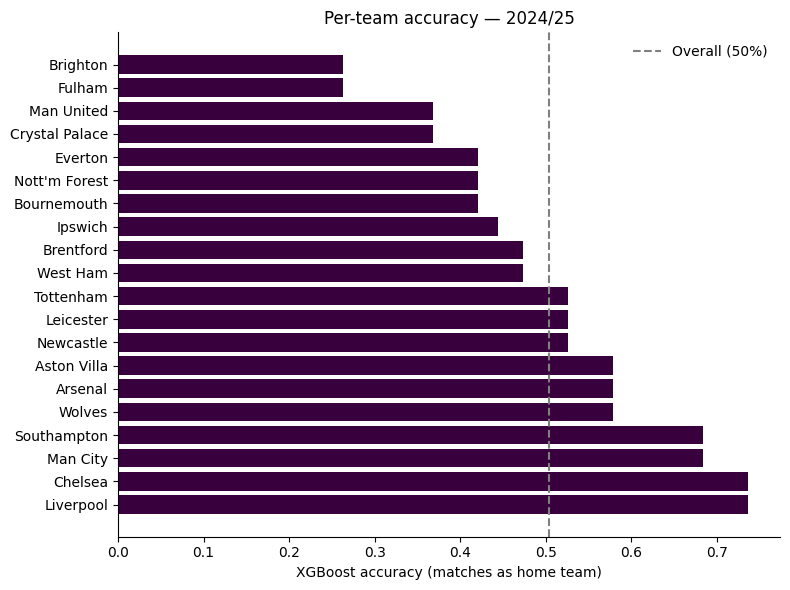

In [30]:
# Accuracy by team (when they're home)
test_with_pred = test.copy()
test_with_pred['pred_xgb'] = y_pred_xgb
test_with_pred['correct']  = (test_with_pred['pred_xgb'] == test_with_pred['FTR']).astype(int)

per_team = (
    test_with_pred.groupby('HomeTeam')
                  .agg(matches=('correct', 'size'),
                       accuracy=('correct', 'mean'))
                  .sort_values('accuracy', ascending=False)
)
per_team = per_team[per_team['matches'] >= 5]

fig, ax = plt.subplots(figsize=(8, max(4, len(per_team) * 0.3)))
ax.barh(per_team.index, per_team['accuracy'].values, color='#38003C')
ax.axvline(acc_xgb, linestyle='--', color='gray',
           label=f'Overall ({acc_xgb:.0%})')
ax.set_xlabel('XGBoost accuracy (matches as home team)')
ax.set_title('Per-team accuracy — 2024/25')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 17. Limitations & honest reading

What this project does well:
- Time-based split that respects causality; no leakage between train and test
- Three benchmarks (naive / model / market) that frame results honestly
- Two independent test seasons (2024/25 and 2025/26) showing stable performance
- Multiple markets (1X2, Over 2.5, BTTS) using the same disciplined pipeline
- Calibration and confidence analyses, not just accuracy

What it doesn't do — and why:
- **No expected goals (xG)** — would require an additional data source (e.g. Understat). xG captures *chance quality*, not just chance count, and is widely used in modern football analytics. This is the single biggest feature gap.
- **No team news** — no lineups, no injuries, no transfers. Bookmakers have these and we don't, which is part of why their accuracy ceiling is hard to reach.
- **No hyperparameter tuning** — a deliberate choice. With a single one-season test set, aggressive tuning would risk overfitting to that season's idiosyncrasies more than it would generalise. The numbers reported here are from default-class hyperparameters.
- **No walk-forward retraining** — for deployment you'd refit after each season. Out of scope here.
- **No betting-profitability analysis** — accuracy is not P&L. Beating accuracy at the bookmaker's posted odds, after the margin, requires far more careful backtesting.
- **Two test seasons is a small sample.** Even if XGBoost edges Bet365 on 2025/26, this is not evidence of an "edge."

Where the model breaks down:
- Matches with very close Elo and similar form (the high-draw-probability region) — calibration is weakest here.
- Newly-promoted teams in the first half of their first PL season — short history, unstable form features.
- Post-international-break weekends — injuries and fatigue aren't in our features.

## 18. Conclusion

Across the three football betting markets covered — 1X2, Over 2.5 goals, and Both Teams to Score — the same disciplined pipeline produces the same pattern of result.

**On the 1X2 market**, both Logistic Regression and XGBoost clearly beat the naive baseline on the 2024/25 test season (about 10 percentage points above always-predict-home) and trail the Bet365 closing-odds baseline by a few percentage points. On the independent 2025/26 hold-out (loaded fresh from football-data.co.uk and feature-engineered using the same procedure), the models remain stable — accuracy does not collapse, which is the relevant evidence against overfitting.

**On Over 2.5 and BTTS**, the same pipeline applied to two binary targets follows the same pattern: a clear gain over the naive base rate, and a smaller gap to the bookmaker (where over/under odds are available). The cross-season comparison shows stable performance on both markets.

**The most informative single finding is the consistency of the model-to-bookmaker gap.** Across three markets, two test seasons, and two model families, the distance to the bookmaker stays roughly the same size. That distance is not a model-quality problem in the conventional sense — it reflects information the bookmaker has and the project does not (starting lineups, late team news, injury updates, and the money flow that the market itself observes).

**On modeling choices**: adding Club Elo ratings and cumulative season points moved accuracy more than switching between Logistic Regression and XGBoost. On these features, the two model families perform within a percentage point of each other. The features carry the work, not the algorithm.

**On reading the numbers honestly**: raw accuracy alone is misleading. The confusion matrices show that both models almost never predict draws — the noisiest class. Calibration shows where the probabilities themselves are over- or under-confident, particularly in the 40–60% home-win region where draws cluster. Selective predictions show that accuracy on the model's top-confidence picks is substantially higher than the headline average — useful in any decision context where the cost of acting on a low-confidence prediction is non-trivial.